In [5]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)


iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)
iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)


cresta_conf = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet"
)
cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta = cresta_conf.join(
    cresta_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

# pdb_v_conf = pl.read_parquet(
#     "../../data/pdb/triad/staged/pdb_validation_triad.conf_af3.parquet"
# )
# pdb_v_tcrdock = pl.read_parquet(
#     "../../data/pdb/triad/staged/pdb_validation_triad.af3_tcrdock.parquet"
# )
# pdb_v = pdb_v_conf.join(
#     pdb_v_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
#         pl.col("pred_dgeom_4").struct.unnest()
#     ),
#     on="job_name",
#     how="inner",
# )


template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)
class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

class_I_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "I").select("dgeom").to_series()
)
class_I_distr = mn_distr_from_dgeom_ndarr(class_I_t_dgeom)


def dgeom_col(df, distr):
    _, p_dgeom = mn_distance_from(
        dgeom_ndarr_from_dgeom_series(df.select("pred_dgeom_4").to_series()),
        *distr,
    )
    df = df.with_columns(pl.Series(name="p_dgeom", values=p_dgeom))
    return df


iedb_II = dgeom_col(iedb_II, class_II_distr)
cresta = dgeom_col(cresta, class_II_distr)
# pdb_v = dgeom_col(pdb_v, class_I_distr)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_correlation(
    x: np.ndarray,
    y: np.ndarray,
    xlabel: str,
    ylabel: str,
    method: str = "spearman",
    title: str | None = None,
):
    method = method.lower()
    if method == "pearson":
        r, p = stats.pearsonr(x, y)
    elif method == "spearman":
        r, p = stats.spearmanr(x, y)
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    fig, ax = plt.subplots()

    ax.scatter(x, y, alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.text(
        0.05,
        0.95,
        f"{method.title()} r = {r:.2f}, p = {p:.2g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6),
    )
    plt.tight_layout()
    return fig

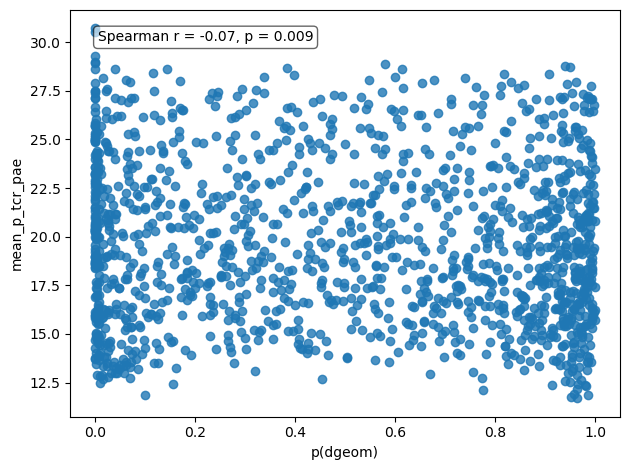

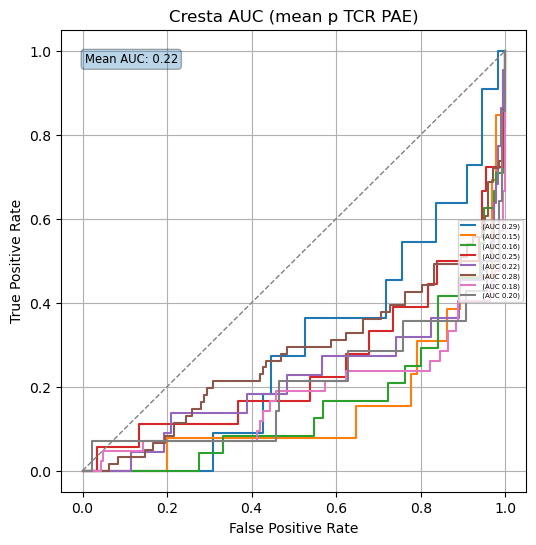

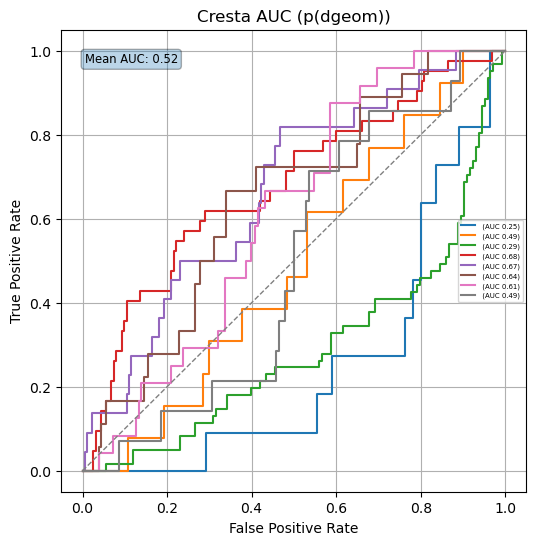

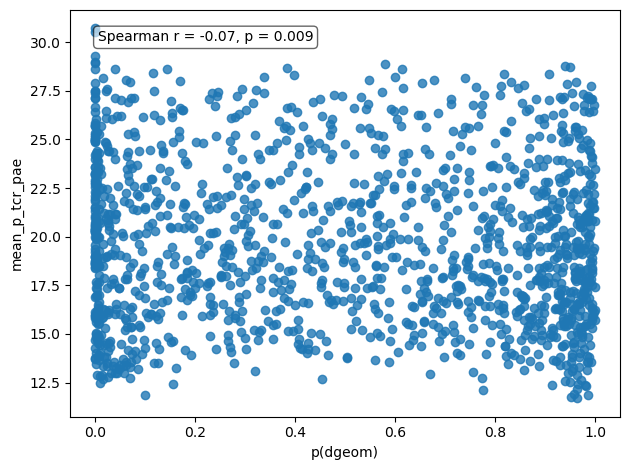

In [8]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

cresta_auc_conf = antigen_raw_score_auc(
    cresta,
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(
    cresta_auc_conf,
    title="Cresta AUC (mean p TCR PAE)",
)

cresta_auc_dgeom = antigen_raw_score_auc(
    cresta,
    "p_dgeom",
)
plot_auc_per_antigen(
    cresta_auc_dgeom,
    title="Cresta AUC (p(dgeom))",
)

plot_correlation(
    cresta.select("p_dgeom").to_series().to_numpy(),
    cresta.select("mean_p_tcr_pae").to_series().to_numpy(),
    xlabel="p(dgeom)",
    ylabel="mean_p_tcr_pae",
    title="Cresta",
)

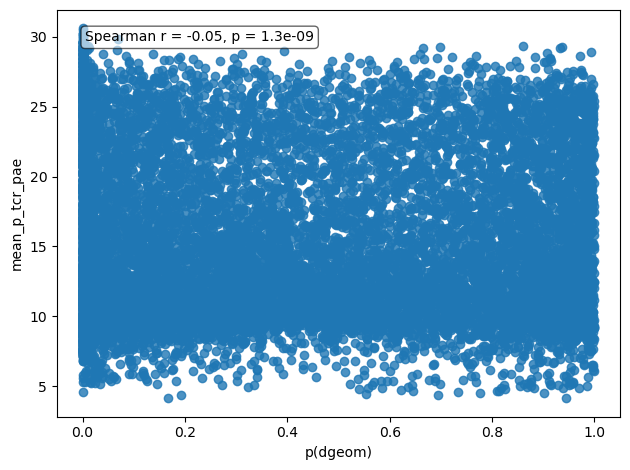

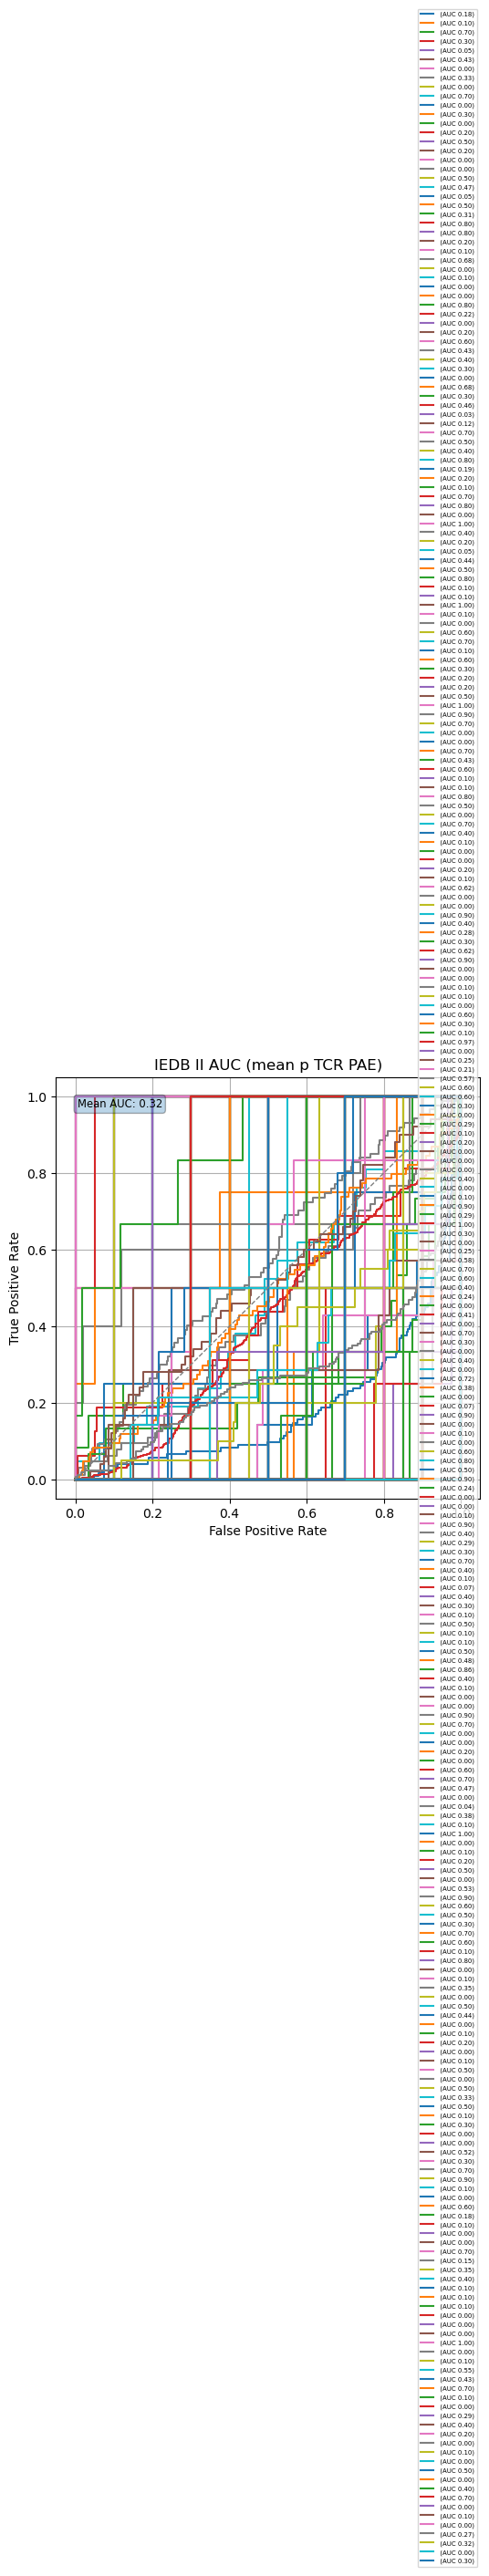

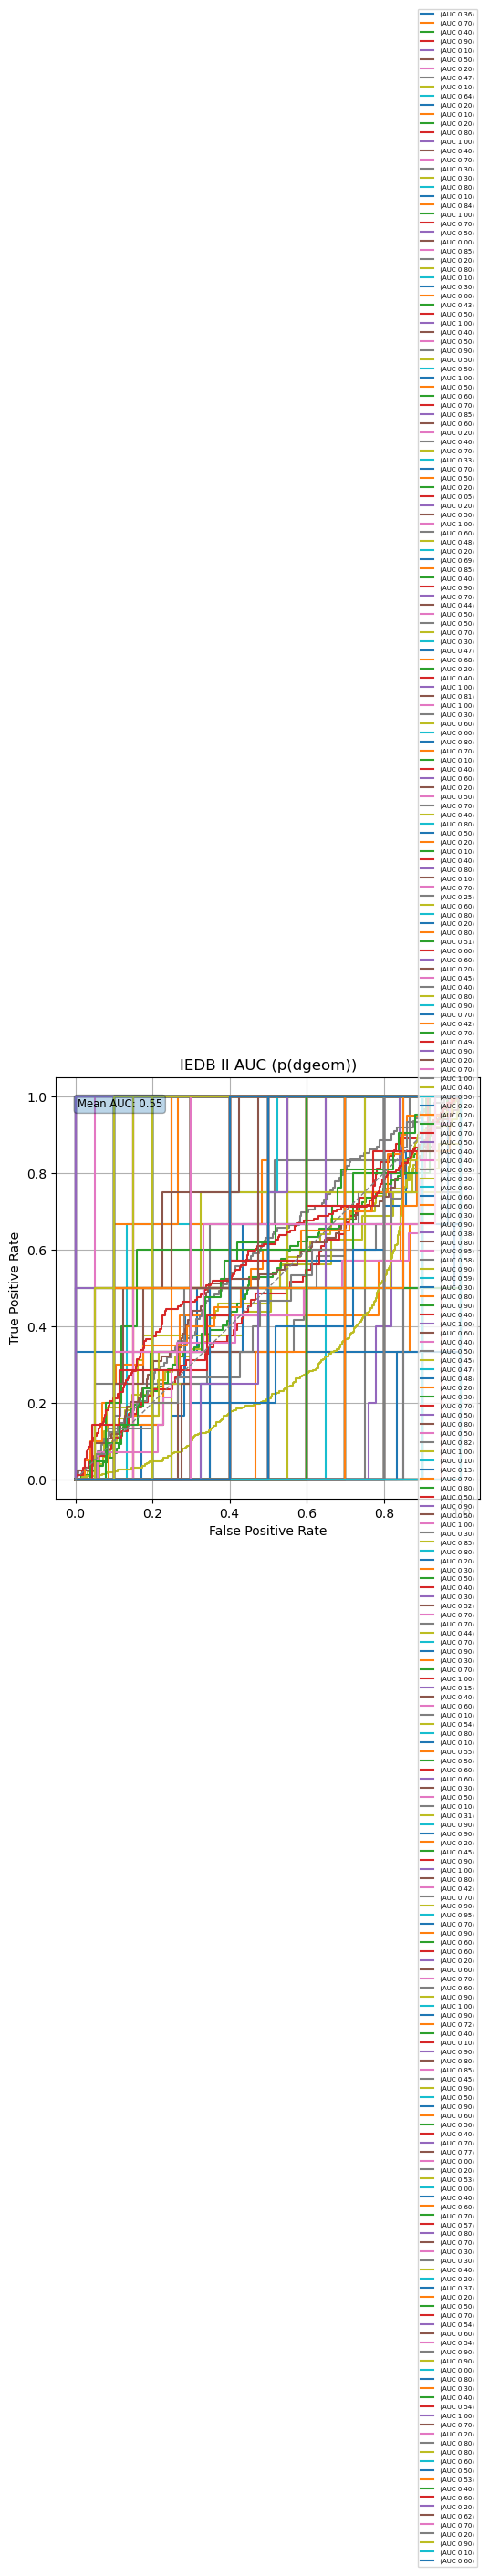

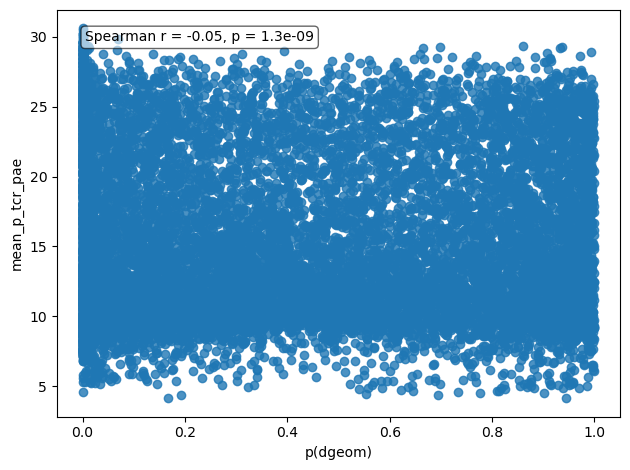

In [9]:
iedb_II_auc_conf = antigen_raw_score_auc(
    iedb_II,
    "mean_p_tcr_pae",
)
plot_auc_per_antigen(
    iedb_II_auc_conf,
    title="IEDB II AUC (mean p TCR PAE)",
)
iedb_II_auc_dgeom = antigen_raw_score_auc(
    iedb_II,
    "p_dgeom",
)
plot_auc_per_antigen(
    iedb_II_auc_dgeom,
    title="IEDB II AUC (p(dgeom))",
)

plot_correlation(
    iedb_II.select("p_dgeom").to_series().to_numpy(),
    iedb_II.select("mean_p_tcr_pae").to_series().to_numpy(),
    xlabel="p(dgeom)",
    ylabel="mean_p_tcr_pae",
    title="IEDB II",
)